## **1° Module**: TT - Exploratory Data Analysis (EDA)
* April  22°, 2026
#### ESCOM - IPN:

#### *B.S. in Computer Science*
> Miguel Alexander Sanchez Garcia

#### **0° Introduction**

* Data obtained from:

> Sawyer-Lee, R., Gimenez, F., Hoogi, A., & Rubin, D. (2016). Curated Breast Imaging Subset of Digital Database for Screening Mammography (CBIS-DDSM) [Data set]. The Cancer Imaging Archive. https://doi.org/10.7937/K9/TCIA.2016.7O02S9CY

#### **1° Data Load & Cleaning**

**a.** Import the necessaty libraries

In [2]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pydicom
from pathlib import Path
from collections import defaultdict

**b.** Set the paths

In [3]:
# BASE directory for data files
BASE = Path("/Users/alexander_san/TT/Data") 

# CSV filenames
CSV_FILES = {
    "mass_train" : BASE / "mass_case_description_train_set.csv",
    "mass_test"  : BASE / "mass_case_description_test_set.csv",
    "calc_train" : BASE / "calc_case_description_train_set.csv",
    "calc_test"  : BASE / "calc_case_description_test_set.csv",
}

# Check if files exist
print("Paths configured.")
for key, path in CSV_FILES.items():
    status = "OK" if path.exists() else "NOT FOUND"
    print(f"  {key:15s}: {status}  ->  {path.name}")

Paths configured.
  mass_train     : OK  ->  mass_case_description_train_set.csv
  mass_test      : OK  ->  mass_case_description_test_set.csv
  calc_train     : OK  ->  calc_case_description_train_set.csv
  calc_test      : OK  ->  calc_case_description_test_set.csv


**c.** Concatenate the dataframes

In [4]:
def load_cbis_ddsm_csvs(csv_files: dict) -> pd.DataFrame:
    """
    Load and concatenate the CBIS-DDSM CSV files into a single DataFrame.
    Adds 'finding_type' (mass/calc) and 'split' (train/test) columns.

    Parameters
    ----------
    csv_files : dict
        Dictionary mapping dataset keys to file paths.

    Returns
    -------
    pd.DataFrame
        Unified DataFrame with all cases.
    """
    frames = []
    for key, path in csv_files.items():
        split = key.split("_")[1]
        df = pd.read_csv(path)
        df["split"] = split 
        frames.append(df)
        print(f"Loaded {key:15s}: {len(df):>4d} rows  |  {df.shape[1]} columns")

    unified = pd.concat(frames, ignore_index=True)
    print(f"\nTotal rows after concatenation: {len(unified)}")
    return unified


df = load_cbis_ddsm_csvs(CSV_FILES)
df

Loaded mass_train     : 1318 rows  |  15 columns
Loaded mass_test      :  378 rows  |  15 columns
Loaded calc_train     : 1546 rows  |  15 columns
Loaded calc_test      :  326 rows  |  15 columns

Total rows after concatenation: 3568


,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path,split,breast density,calc type,calc distribution
0,P_00001,3.0,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,train,NaN,NaN,NaN
1,P_00001,3.0,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,train,NaN,NaN,NaN
2,P_00004,3.0,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,train,NaN,NaN,NaN
3,P_00004,3.0,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,train,NaN,NaN,NaN
4,P_00004,3.0,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,train,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3563,P_02464,NaN,RIGHT,MLO,1,calcification,NaN,NaN,0,MALIGNANT,4,Calc-Test_P_02464_RIGHT_MLO/1.3.6.1.4.1.9590.1...,Calc-Test_P_02464_RIGHT_MLO_1/1.3.6.1.4.1.9590...,Calc-Test_P_02464_RIGHT_MLO_1/1.3.6.1.4.1.9590...,test,2.0,FINE_LINEAR_BRANCHING,CLUSTERED
3564,P_02498,NaN,RIGHT,CC,1,calcification,NaN,NaN,0,BENIGN,3,Calc-Test_P_02498_RIGHT_CC/1.3.6.1.4.1.9590.10...,Calc-Test_P_02498_RIGHT_CC_1/1.3.6.1.4.1.9590....,Calc-Test_P_02498_RIGHT_CC_1/1.3.6.1.4.1.9590....,test,4.0,PUNCTATE,CLUSTERED
3565,P_02498,NaN,RIGHT,MLO,1,calcification,NaN,NaN,0,BENIGN,3,Calc-Test_P_02498_RIGHT_MLO/1.3.6.1.4.1.9590.1...,Calc-Test_P_02498_RIGHT_MLO_1/1.3.6.1.4.1.9590...,Calc-Test_P_02498_RIGHT_MLO_1/1.3.6.1.4.1.9590...,test,4.0,PUNCTATE,CLUSTERED
3566,P_02501,NaN,RIGHT,CC,1,calcification,NaN,NaN,0,MALIGNANT,3,Calc-Test_P_02501_RIGHT_CC/1.3.6.1.4.1.9590.10...,Calc-Test_P_02501_RIGHT_CC_1/1.3.6.1.4.1.9590....,Calc-Test_P_02501_RIGHT_CC_1/1.3.6.1.4.1.9590....,test,3.0,PLEOMORPHIC,CLUSTERED


c. Clean the pathology feature

In [5]:
df["pathology"] = df["pathology"].str.strip().str.replace("_WITHOUT_CALLBACK", "", regex=False)

label_map = {"BENIGN": 0, "MALIGNANT": 1}
df["label"] = df["pathology"].map(label_map)

df

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path,split,breast density,calc type,calc distribution,label
0,P_00001,3.0,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,train,NaN,NaN,NaN,1
1,P_00001,3.0,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,train,NaN,NaN,NaN,1
2,P_00004,3.0,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,train,NaN,NaN,NaN,0
3,P_00004,3.0,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,train,NaN,NaN,NaN,0
4,P_00004,3.0,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,train,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3563,P_02464,NaN,RIGHT,MLO,1,calcification,NaN,NaN,0,MALIGNANT,4,Calc-Test_P_02464_RIGHT_MLO/1.3.6.1.4.1.9590.1...,Calc-Test_P_02464_RIGHT_MLO_1/1.3.6.1.4.1.9590...,Calc-Test_P_02464_RIGHT_MLO_1/1.3.6.1.4.1.9590...,test,2.0,FINE_LINEAR_BRANCHING,CLUSTERED,1
3564,P_02498,NaN,RIGHT,CC,1,calcification,NaN,NaN,0,BENIGN,3,Calc-Test_P_02498_RIGHT_CC/1.3.6.1.4.1.9590.10...,Calc-Test_P_02498_RIGHT_CC_1/1.3.6.1.4.1.9590....,Calc-Test_P_02498_RIGHT_CC_1/1.3.6.1.4.1.9590....,test,4.0,PUNCTATE,CLUSTERED,0
3565,P_02498,NaN,RIGHT,MLO,1,calcification,NaN,NaN,0,BENIGN,3,Calc-Test_P_02498_RIGHT_MLO/1.3.6.1.4.1.9590.1...,Calc-Test_P_02498_RIGHT_MLO_1/1.3.6.1.4.1.9590...,Calc-Test_P_02498_RIGHT_MLO_1/1.3.6.1.4.1.9590...,test,4.0,PUNCTATE,CLUSTERED,0
3566,P_02501,NaN,RIGHT,CC,1,calcification,NaN,NaN,0,MALIGNANT,3,Calc-Test_P_02501_RIGHT_CC/1.3.6.1.4.1.9590.10...,Calc-Test_P_02501_RIGHT_CC_1/1.3.6.1.4.1.9590....,Calc-Test_P_02501_RIGHT_CC_1/1.3.6.1.4.1.9590....,test,3.0,PLEOMORPHIC,CLUSTERED,1


**d.** Unify the "breast_density" feature

In [6]:
df['breast_density'] = df['breast_density'].combine_first(df['breast density'])

df.drop(columns=["breast density"], inplace=True)

df

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path,split,calc type,calc distribution,label
0,P_00001,3.0,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,train,NaN,NaN,1
1,P_00001,3.0,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,train,NaN,NaN,1
2,P_00004,3.0,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,train,NaN,NaN,0
3,P_00004,3.0,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,train,NaN,NaN,0
4,P_00004,3.0,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,train,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3563,P_02464,2.0,RIGHT,MLO,1,calcification,NaN,NaN,0,MALIGNANT,4,Calc-Test_P_02464_RIGHT_MLO/1.3.6.1.4.1.9590.1...,Calc-Test_P_02464_RIGHT_MLO_1/1.3.6.1.4.1.9590...,Calc-Test_P_02464_RIGHT_MLO_1/1.3.6.1.4.1.9590...,test,FINE_LINEAR_BRANCHING,CLUSTERED,1
3564,P_02498,4.0,RIGHT,CC,1,calcification,NaN,NaN,0,BENIGN,3,Calc-Test_P_02498_RIGHT_CC/1.3.6.1.4.1.9590.10...,Calc-Test_P_02498_RIGHT_CC_1/1.3.6.1.4.1.9590....,Calc-Test_P_02498_RIGHT_CC_1/1.3.6.1.4.1.9590....,test,PUNCTATE,CLUSTERED,0
3565,P_02498,4.0,RIGHT,MLO,1,calcification,NaN,NaN,0,BENIGN,3,Calc-Test_P_02498_RIGHT_MLO/1.3.6.1.4.1.9590.1...,Calc-Test_P_02498_RIGHT_MLO_1/1.3.6.1.4.1.9590...,Calc-Test_P_02498_RIGHT_MLO_1/1.3.6.1.4.1.9590...,test,PUNCTATE,CLUSTERED,0
3566,P_02501,3.0,RIGHT,CC,1,calcification,NaN,NaN,0,MALIGNANT,3,Calc-Test_P_02501_RIGHT_CC/1.3.6.1.4.1.9590.10...,Calc-Test_P_02501_RIGHT_CC_1/1.3.6.1.4.1.9590....,Calc-Test_P_02501_RIGHT_CC_1/1.3.6.1.4.1.9590....,test,PLEOMORPHIC,CLUSTERED,1


**e.** Build DICOM file index

In [ ]:
def build_dicom_index(dicom_root: Path) -> dict:
    """
    Scan the CBIS-DDSM directory and build an index mapping each level-1 folder name to all .dcm files it contains.

    Actual disk structure:
        <root>/
          <PatientFolder>/          ← level 1, matches CSV path[0]
            <StudyFolder>/          ← level 2 (date-based name)
              <SeriesFolder>/       ← level 3 (descriptive name)
                1-1.dcm             ← actual file

    CSV path structure:
        <PatientFolder>/            ← same as level-1 folder
          <StudyUID>/               
            <SeriesUID>/
              000000.dcm            ← different filename

    Strategy: match ONLY on level-1 folder name, then find
    the actual .dcm files inside regardless of subfolders.

    Parameters
    ----------
    dicom_root : Path
        Path to CBIS-DDSM root folder.

    Returns
    -------
    dict
        {level1_folder_name (str): [Path, ...]}
    """
    index = defaultdict(list)

    print(f"Scanning: {dicom_root}")

    # Get all level-1 subdirectories
    level1_dirs = [d for d in dicom_root.iterdir() if d.is_dir()]
    print(f"Level-1 folders found: {len(level1_dirs)}")

    for level1_dir in level1_dirs:
        folder_name = level1_dir.name
        dcm_files   = list(level1_dir.rglob("*.dcm"))
        if dcm_files:
            index[folder_name].extend(dcm_files)

    total_files = sum(len(v) for v in index.values())
    print(f"Total .dcm files indexed: {total_files}")
    print(f"Unique level-1 folders with .dcm files: {len(index)}")

    return dict(index)


dicom_index = build_dicom_index(BASE / "CBIS-DDSM")

# Preview 3 entries
print("\nSample index entries:")
for folder, paths in list(dicom_index.items())[:3]:
    print(f"\n  [{folder}]")
    for p in paths:
        size_mb = p.stat().st_size / 1024**2
        print(f"    {p.name}  ({size_mb:.1f} MB)")

Scanning: /Users/alexander_san/TT/Data/CBIS-DDSM
Level-1 folders found: 6671
Total .dcm files indexed: 10239
Unique level-1 folders with .dcm files: 6671

Sample index entries:

  [Calc-Training_P_00991_LEFT_CC_1]
    1-2.dcm  (13.3 MB)
    1-1.dcm  (0.0 MB)

  [Mass-Training_P_01844_RIGHT_MLO_1]
    1-2.dcm  (0.4 MB)
    1-1.dcm  (12.7 MB)

  [Mass-Training_P_00703_LEFT_MLO]
    1-1.dcm  (35.3 MB)


**f.** Check if all CSV entries have corresponding DICOM files

In [11]:
def extract_level1_folder(csv_path: str) -> str:
    """
    Extract the level-1 folder name from a CSV path string.

    CSV path example:
        'Mass-Training_P_00001_LEFT_CC/1.3.6.../1.3.6.../000000.dcm'

    Returns:
        'Mass-Training_P_00001_LEFT_CC'
    """
    if pd.isna(csv_path):
        return None
    parts = str(csv_path).replace("\\", "/").strip().split("/")
    return parts[0] if parts else None


def classify_dicom_file(dcm_path: Path) -> str:
    """
    Read DICOM metadata to determine file type:
        'mask'    → binary ROI mask (pixel values 0 or 255, SamplesPerPixel=1,
                    very few unique values)
        'cropped' → cropped mammogram (many unique pixel values)
        'full'    → full mammogram (large image, many unique values)
        'unknown' → cannot determine

    Parameters
    ----------
    dcm_path : Path
        Path to a .dcm file.

    Returns
    -------
    str
        One of: 'mask', 'cropped', 'full', 'unknown'
    """
    try:
        ds     = pydicom.dcmread(str(dcm_path), stop_before_pixels=False)
        pixels = ds.pixel_array
        rows   = int(ds.Rows)
        cols   = int(ds.Columns)
        n_unique = len(np.unique(pixels))

        # masks are binary: only 2 unique values (0 and 255 or 0 and 1)
        if n_unique <= 2:
            return "mask"

        # distinguish full mammogram from cropped by size
        # full mammograms are typically > 1000px in both dimensions
        if rows > 1000 and cols > 1000:
            return "full"

        return "cropped"

    except Exception:
        return "unknown"


def resolve_roi_folder(level1_folder: str,
                       dicom_index: dict) -> dict:
    """
    Given a level-1 folder name that contains both mask and cropped files,
    classify each .dcm file by reading its pixel content and return
    resolved paths.

    Parameters
    ----------
    level1_folder : str
        Level-1 folder name (the _1 suffixed folder).
    dicom_index : dict
        Index built by build_dicom_index().

    Returns
    -------
    dict with keys 'mask' and 'cropped', values are Path or None.
    """
    result = {"mask": None, "cropped": None}

    if level1_folder is None or level1_folder not in dicom_index:
        return result

    for dcm_path in dicom_index[level1_folder]:
        file_type = classify_dicom_file(dcm_path)
        if file_type == "mask" and result["mask"] is None:
            result["mask"] = dcm_path
        elif file_type == "cropped" and result["cropped"] is None:
            result["cropped"] = dcm_path

    return result


def crossref_csv_with_disk(df: pd.DataFrame,
                            dicom_index: dict) -> pd.DataFrame:
    """
    Resolve actual .dcm file paths on disk for each CSV record.

    For the full mammogram folder (no _1 suffix):
        → single .dcm file = full mammogram

    For the ROI folder (_1 suffix):
        → reads pixel content to distinguish mask vs cropped

    Adds columns:
        path_full_mammo  → full mammogram .dcm
        path_roi_mask    → ROI binary mask .dcm
        path_cropped     → cropped ROI image .dcm
        dicom_found      → bool: full mammogram found on disk
    """
    df = df.copy()

    # extract level-1 folder names from CSV paths
    df["folder_full"] = df["image file path"].apply(
        extract_level1_folder)
    df["folder_roi"]  = df["ROI mask file path"].apply(
        extract_level1_folder)

    # resolve full mammogram (single file in folder)
    df["path_full_mammo"] = df["folder_full"].apply(
        lambda f: dicom_index[f][0] if f and f in dicom_index
                  and len(dicom_index[f]) > 0 else None
    )

    # resolve mask and cropped by reading pixel content
    print("Classifying ROI and cropped files by pixel content...")
    print("(This may take a few minutes for large datasets)")

    roi_results = {}
    unique_roi_folders = df["folder_roi"].dropna().unique()
    total = len(unique_roi_folders)

    for i, folder in enumerate(unique_roi_folders):
        if i % 50 == 0:
            print(f"  Processing {i}/{total} folders...")
        roi_results[folder] = resolve_roi_folder(folder, dicom_index)

    df["path_roi_mask"] = df["folder_roi"].apply(
        lambda f: roi_results.get(f, {}).get("mask") if f else None
    )
    df["path_cropped"]  = df["folder_roi"].apply(
        lambda f: roi_results.get(f, {}).get("cropped") if f else None
    )

    df["dicom_found"] = df["path_full_mammo"].notna()

    return df


df = crossref_csv_with_disk(df, dicom_index)

# Summary
found   = df["dicom_found"].sum()
missing = (~df["dicom_found"]).sum()
pct     = found / len(df) * 100

print(f"\nRecords with full mammogram on disk : {found:>4d}  ({pct:.1f}%)")
print(f"Records WITHOUT full mammogram      : {missing:>4d}")

# Verify the same sample record
print("\nSample resolved paths (first record):")
sample = df[df["path_cropped"].notna()].iloc[0]
print(f"  patient_id  : {sample['patient_id']}")
print(f"  pathology   : {sample['pathology']}")
print(f"  full_mammo  : {sample['path_full_mammo'].name}")
print(f"  roi_mask    : {sample['path_roi_mask'].name if sample['path_roi_mask'] else 'None'}")
print(f"  cropped     : {sample['path_cropped'].name if sample['path_cropped'] else 'None'}")

# Verify classification is correct
print("\nVerification — pixel stats of resolved files:")
if sample["path_roi_mask"]:
    mask_pixels = pydicom.dcmread(str(sample["path_roi_mask"])).pixel_array
    print(f"  roi_mask unique values : {np.unique(mask_pixels)} ← should be [0, 255] or [0, 1]")
if sample["path_cropped"]:
    crop_pixels = pydicom.dcmread(str(sample["path_cropped"])).pixel_array
    print(f"  cropped unique values  : {len(np.unique(crop_pixels))} ← should be > 100")

Classifying ROI and cropped files by pixel content...
(This may take a few minutes for large datasets)
  Processing 0/3568 folders...
  Processing 50/3568 folders...
  Processing 100/3568 folders...
  Processing 150/3568 folders...
  Processing 200/3568 folders...
  Processing 250/3568 folders...
  Processing 300/3568 folders...
  Processing 350/3568 folders...
  Processing 400/3568 folders...
  Processing 450/3568 folders...
  Processing 500/3568 folders...
  Processing 550/3568 folders...
  Processing 600/3568 folders...
  Processing 650/3568 folders...
  Processing 700/3568 folders...
  Processing 750/3568 folders...
  Processing 800/3568 folders...
  Processing 850/3568 folders...
  Processing 900/3568 folders...
  Processing 950/3568 folders...
  Processing 1000/3568 folders...
  Processing 1050/3568 folders...
  Processing 1100/3568 folders...
  Processing 1150/3568 folders...
  Processing 1200/3568 folders...
  Processing 1250/3568 folders...
  Processing 1300/3568 folders...
  

**g.** Save the cleaned dataframe for future use

In [12]:
output_path = BASE / "cbis_ddsm_unified.csv"
df.to_csv(output_path, index=False)
print(f"Saved: {output_path}")
print(f"Shape: {df.shape}")

Saved: /Users/alexander_san/TT/Data/cbis_ddsm_unified.csv
Shape: (3568, 25)


**h.** Summary 

In [16]:
print("=" * 55)
print("LOAD & VALIDATION SUMMARY")
print("=" * 55)
print(f"  Total records          : {len(df)}")
print(f"  Mass cases             : {(df['abnormality type']=='mass').sum()}")
print(f"  Calc cases             : {(df['abnormality type']=='calcification').sum()}")
print(f"  Train split            : {(df['split']=='train').sum()}")
print(f"  Test split             : {(df['split']=='test').sum()}")
print(f"  Benign  (label=0)      : {(df['label']==0).sum()}")
print(f"  Malignant (label=1)    : {(df['label']==1).sum()}")
print(f"  Null labels            : {df['label'].isna().sum()}")
print(f"  DICOM found on disk    : {df['dicom_found'].sum()}")
print(f"  ROI mask resolved      : {df['path_roi_mask'].notna().sum()}")
print(f"  Cropped resolved       : {df['path_cropped'].notna().sum()}")

print("=" * 55)

LOAD & VALIDATION SUMMARY
  Total records          : 3568
  Mass cases             : 1696
  Calc cases             : 1872
  Train split            : 2864
  Test split             : 704
  Benign  (label=0)      : 2111
  Malignant (label=1)    : 1457
  Null labels            : 0
  DICOM found on disk    : 3568
  ROI mask resolved      : 3568
  Cropped resolved       : 3453


#### **2° EDA: Exploratory Data Analysis for Target Variables**

**a.** Global class distribution

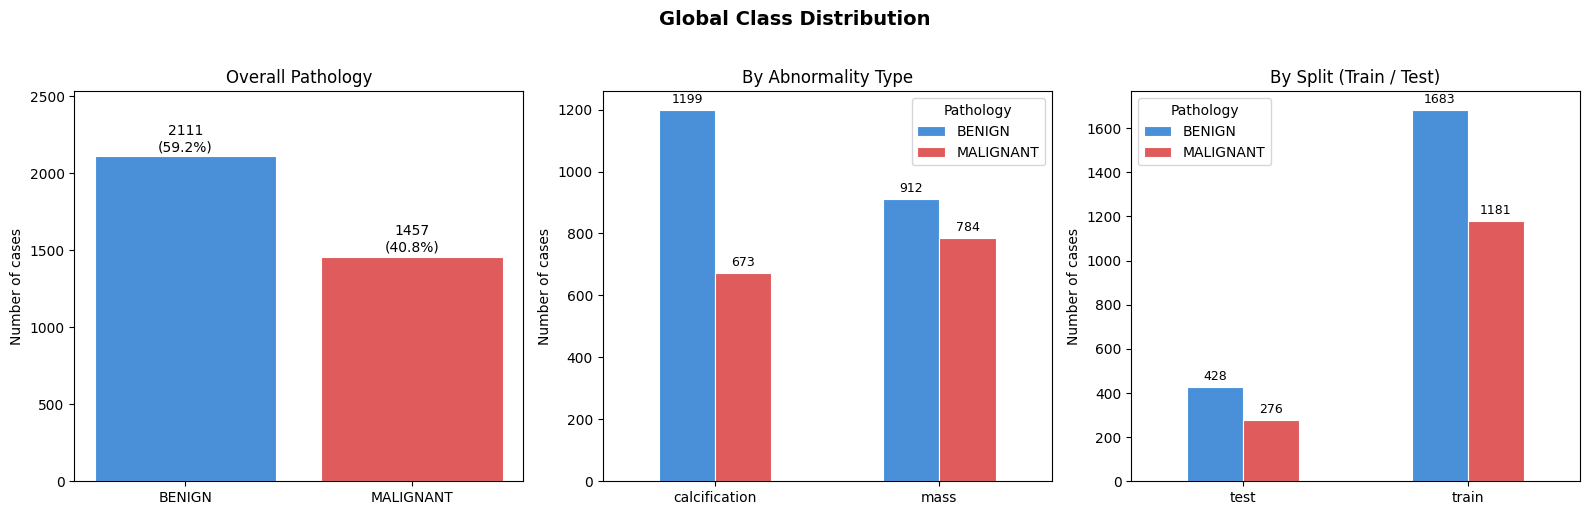

GLOBAL CLASS DISTRIBUTION
pathology
BENIGN       2111
MALIGNANT    1457

Imbalance ratio (benign/malignant): 1.45:1


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Global Class Distribution", fontsize=14, fontweight="bold")

# ── Plot 1: overall label distribution
label_counts = df["pathology"].value_counts()
colors = ["#4A90D9", "#E05C5C"]
bars = axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("Overall Pathology")
axes[0].set_ylabel("Number of cases")
for bar, val in zip(bars, label_counts.values):
    pct = val / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 15,
                 f"{val}\n({pct:.1f}%)",
                 ha="center", va="bottom", fontsize=10)
axes[0].set_ylim(0, label_counts.max() * 1.2)


# Plot 2: by abnormality type
cross = df.groupby(["abnormality type", "pathology"]).size().unstack(fill_value=0)
cross.plot(kind="bar", ax=axes[1], color=colors, edgecolor="white", linewidth=0.8)
axes[1].set_title("By Abnormality Type")
axes[1].set_ylabel("Number of cases")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Pathology")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%d", padding=3, fontsize=9)


# Plot 3: by split
cross_split = df.groupby(["split", "pathology"]).size().unstack(fill_value=0)
cross_split.plot(kind="bar", ax=axes[2], color=colors, edgecolor="white", linewidth=0.8)
axes[2].set_title("By Split (Train / Test)")
axes[2].set_ylabel("Number of cases")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=0)
axes[2].legend(title="Pathology")
for container in axes[2].containers:
    axes[2].bar_label(container, fmt="%d", padding=3, fontsize=9)

plt.tight_layout()
# plt.savefig(BASE / "B1_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Print numeric summary
print("=" * 50)
print("GLOBAL CLASS DISTRIBUTION")
print("=" * 50)
print(df["pathology"].value_counts().to_string())
imbalance = label_counts["BENIGN"] / label_counts["MALIGNANT"]
print(f"\nImbalance ratio (benign/malignant): {imbalance:.2f}:1")

**b.** Distribution by abnormality type

In [ ]:
print("=" * 60)
print("CROSS TABLE: Abnormality Type × Pathology × Split")
print("=" * 60)

cross_full = (df.groupby(["abnormality type", "split", "pathology"]).size().reset_index(name="count"))

pivot = cross_full.pivot_table(
    index=["abnormality type", "split"],
    columns="pathology",
    values="count",
    fill_value=0
)
pivot["TOTAL"] = pivot.sum(axis=1)
pivot["MALIGNANT_%"] = (pivot["MALIGNANT"] / pivot["TOTAL"] * 100).round(1)

print(pivot.to_string())

print("\n")
print("=" * 60)
print("STRATIFICATION CHECK (BI-RADS balance train vs test)")
print("=" * 60)
strat = df.groupby(["split", "assessment"]).size().unstack(fill_value=0)
print(strat.to_string())

CROSS TABLE: Abnormality Type × Pathology × Split
pathology               BENIGN  MALIGNANT   TOTAL  MALIGNANT_%
abnormality type split                                        
calcification    test    197.0      129.0   326.0         39.6
                 train  1002.0      544.0  1546.0         35.2
mass             test    231.0      147.0   378.0         38.9
                 train   681.0      637.0  1318.0         48.3


STRATIFICATION CHECK (BI-RADS balance train vs test)
assessment    0  1    2    3     4    5
split                                  
test         46  2   85  109   347  115
train       192  1  559  368  1286  458


**c.** Class imbalance by abnormality type

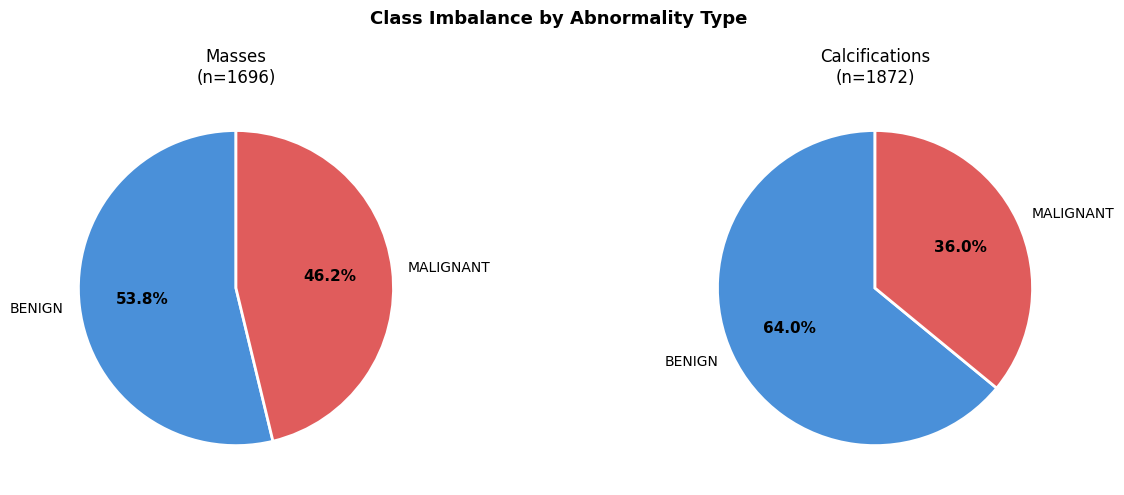

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Class Imbalance by Abnormality Type", fontsize=13, fontweight="bold")

for ax, ftype in zip(axes, ["mass", "calcification"]):
    subset = df[df["abnormality type"] == ftype]["pathology"].value_counts()
    wedge_colors = ["#4A90D9", "#E05C5C"]
    wedges, texts, autotexts = ax.pie(
        subset.values,
        labels=subset.index,
        autopct="%1.1f%%",
        colors=wedge_colors,
        startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 2}
    )
    for at in autotexts:
        at.set_fontsize(11)
        at.set_fontweight("bold")
    title = "Masses" if ftype == "mass" else "Calcifications"
    ax.set_title(f"{title}\n(n={subset.sum()})", fontsize=12)

plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "B2_imbalance_by_finding.png", dpi=150, bbox_inches="tight")
plt.show()

**d.** BI-RADS distribution

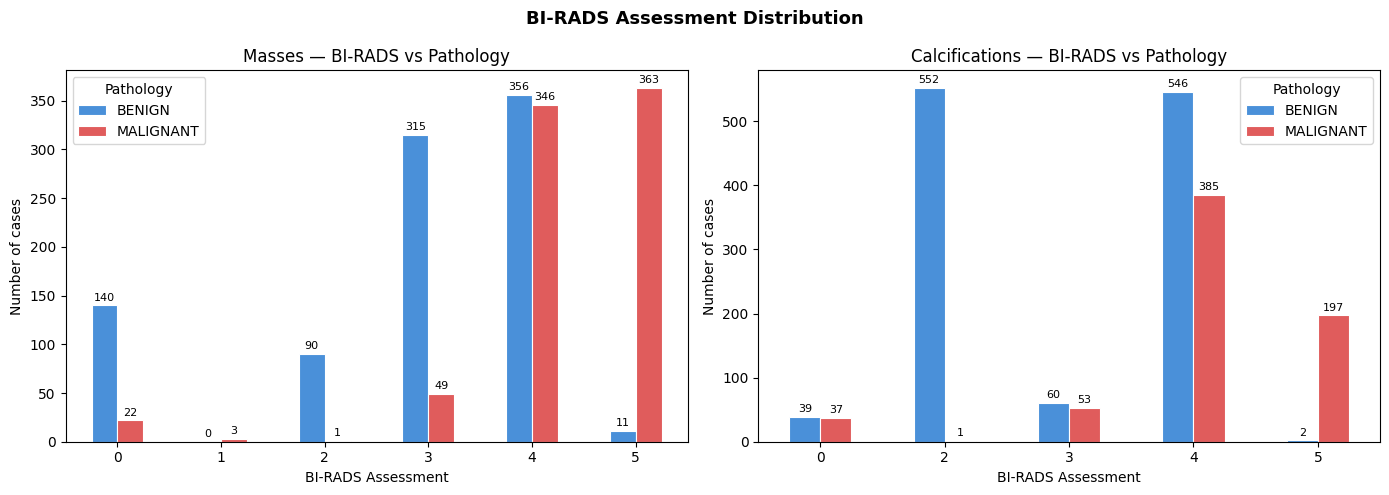

BI-RADS distribution by pathology:
pathology   BENIGN  MALIGNANT
assessment                   
0              179         59
1                0          3
2              642          2
3              375        102
4              902        731
5               13        560


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("BI-RADS Assessment Distribution", fontsize=13, fontweight="bold")

birads_colors = {0: "#AAAAAA", 1: "#6BAF6B", 2: "#4A90D9", 3: "#F0A500", 4: "#E05C5C", 5: "#8B0000"}

for ax, ftype in zip(axes, ["mass", "calcification"]):
    subset = df[df["abnormality type"] == ftype]
    cross = subset.groupby(["assessment", "pathology"]).size().unstack(fill_value=0)
    colors = ["#4A90D9", "#E05C5C"]
    cross.plot(kind="bar", ax=ax, color=colors, edgecolor="white", linewidth=0.8)
    title = "Masses" if ftype == "mass" else "Calcifications"
    ax.set_title(f"{title} — BI-RADS vs Pathology")
    ax.set_xlabel("BI-RADS Assessment")
    ax.set_ylabel("Number of cases")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Pathology")
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=2, fontsize=8)

plt.tight_layout()
# plt.savefig(BASE / "B3_birads_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Numeric summary
print("BI-RADS distribution by pathology:")
print(df.groupby(["assessment", "pathology"]).size().unstack(fill_value=0).to_string())

**e.** Subtlety analysis

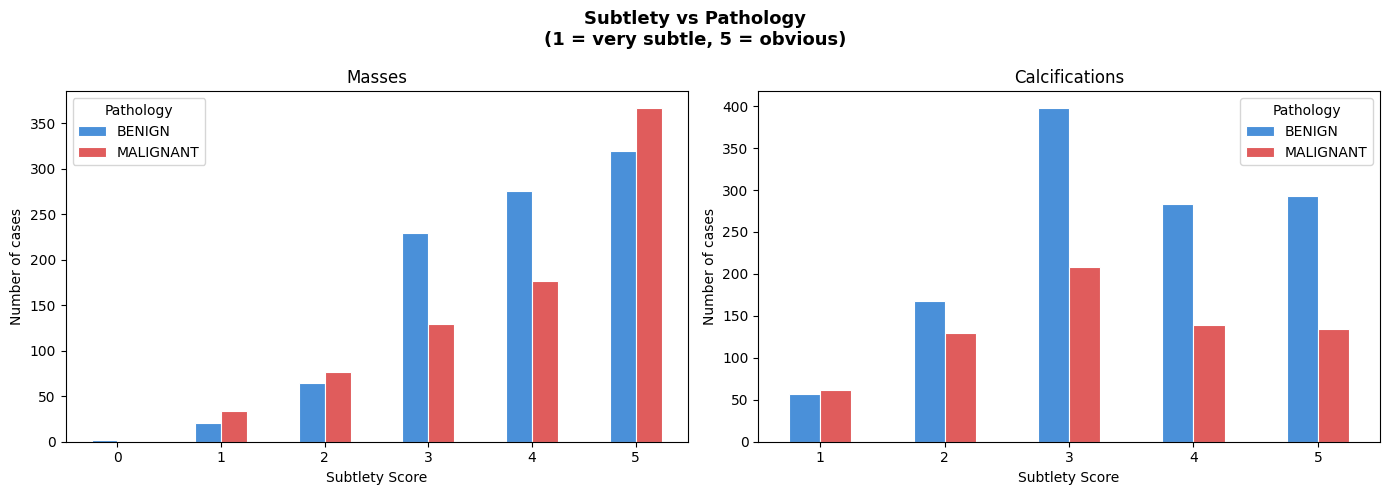

Mean subtlety by pathology and finding type:
                            mean   std  median
abnormality type pathology                    
calcification    BENIGN     3.49  1.14     3.0
                 MALIGNANT  3.23  1.23     3.0
mass             BENIGN     3.88  1.05     4.0
                 MALIGNANT  3.98  1.19     4.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Subtlety vs Pathology\n(1 = very subtle, 5 = obvious)", fontsize=13, fontweight="bold")

for ax, ftype in zip(axes, ["mass", "calcification"]):
    subset = df[df["abnormality type"] == ftype]
    cross = subset.groupby(["subtlety", "pathology"]).size().unstack(fill_value=0)
    colors = ["#4A90D9", "#E05C5C"]
    cross.plot(kind="bar", ax=ax, color=colors, edgecolor="white", linewidth=0.8)
    title = "Masses" if ftype == "mass" else "Calcifications"
    ax.set_title(f"{title}")
    ax.set_xlabel("Subtlety Score")
    ax.set_ylabel("Number of cases")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Pathology")

plt.tight_layout()
# plt.savefig(BASE / "B4_subtlety_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Statistical summary
print("Mean subtlety by pathology and finding type:")
print(df.groupby(["abnormality type", "pathology"])["subtlety"].agg(["mean", "std", "median"]).round(2).to_string())

**f.** Summary

In [ ]:
print("=" * 55)
print("TARGET VARIABLE SUMMARY")
print("=" * 55)

total = len(df)
benign = (df["label"] == 0).sum()
malignant = (df["label"] == 1).sum()
ratio = benign / malignant

print(f"  Total cases            : {total}")
print(f"  Benign   (0)           : {benign}  ({benign/total*100:.1f}%)")
print(f"  Malignant (1)          : {malignant}  ({malignant/total*100:.1f}%)")
print(f"  Imbalance ratio        : {ratio:.2f}:1")
print()

for ftype in ["mass", "calcification"]:
    sub = df[df["abnormality type"] == ftype]
    b = (sub["label"] == 0).sum()
    m = (sub["label"] == 1).sum()
    print(f"  {ftype.upper():5s} — Benign: {b}  Malignant: {m}  "
          f"Ratio: {b/m:.2f}:1")

print()
print("  Key findings for modeling:")
ratio_threshold = 1.5
if ratio > ratio_threshold:
    print(f"  [!] Class imbalance detected (ratio={ratio:.2f}:1).")
    print("      Consider: class_weight='balanced' in MLP or oversampling.")
else:
    print("  [OK] Class balance is acceptable.")
print("=" * 55)

TARGET VARIABLE SUMMARY
  Total cases            : 3568
  Benign   (0)           : 2111  (59.2%)
  Malignant (1)          : 1457  (40.8%)
  Imbalance ratio        : 1.45:1

  MASS  — Benign: 912  Malignant: 784  Ratio: 1.16:1
  CALCIFICATION — Benign: 1199  Malignant: 673  Ratio: 1.78:1

  Key findings for modeling:
  [OK] Class balance is acceptable.


#### **3° EDA: Clinical Features Analysis**

**a.** Breast density distribution

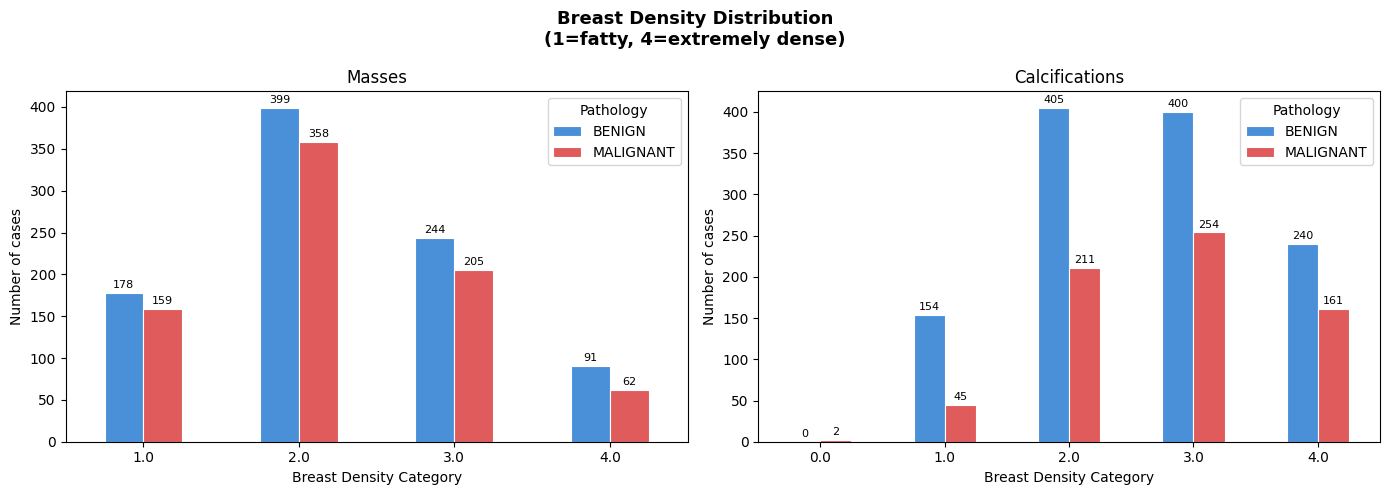

Breast density distribution by pathology:
pathology       BENIGN  MALIGNANT
breast_density                   
0.0                  0          2
1.0                332        204
2.0                804        569
3.0                644        459
4.0                331        223


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Breast Density Distribution\n(1=fatty, 4=extremely dense)", fontsize=13, fontweight="bold")

density_labels = {1: "1-Fatty", 2: "2-Scattered",3: "3-Heterogeneous", 4: "4-Extremely dense"}

for ax, ftype in zip(axes, ["mass", "calcification"]):
    subset = df[df["abnormality type"] == ftype].copy()
    subset["density_label"] = subset["breast_density"].map(density_labels)
    cross = subset.groupby(["breast_density", "pathology"]).size().unstack(fill_value=0)
    colors = ["#4A90D9", "#E05C5C"]
    cross.plot(kind="bar", ax=ax, color=colors, edgecolor="white", linewidth=0.8)
    title = "Masses" if ftype == "mass" else "Calcifications"
    ax.set_title(f"{title}")
    ax.set_xlabel("Breast Density Category")
    ax.set_ylabel("Number of cases")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Pathology")
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=2, fontsize=8)

plt.tight_layout()
# plt.savefig(BASE / "C1_breast_density.png", dpi=150, bbox_inches="tight")
plt.show()

print("Breast density distribution by pathology:")
print(df.groupby(["breast_density", "pathology"]).size().unstack(fill_value=0).to_string())

**b.** Laterality and Mammographic view distribution

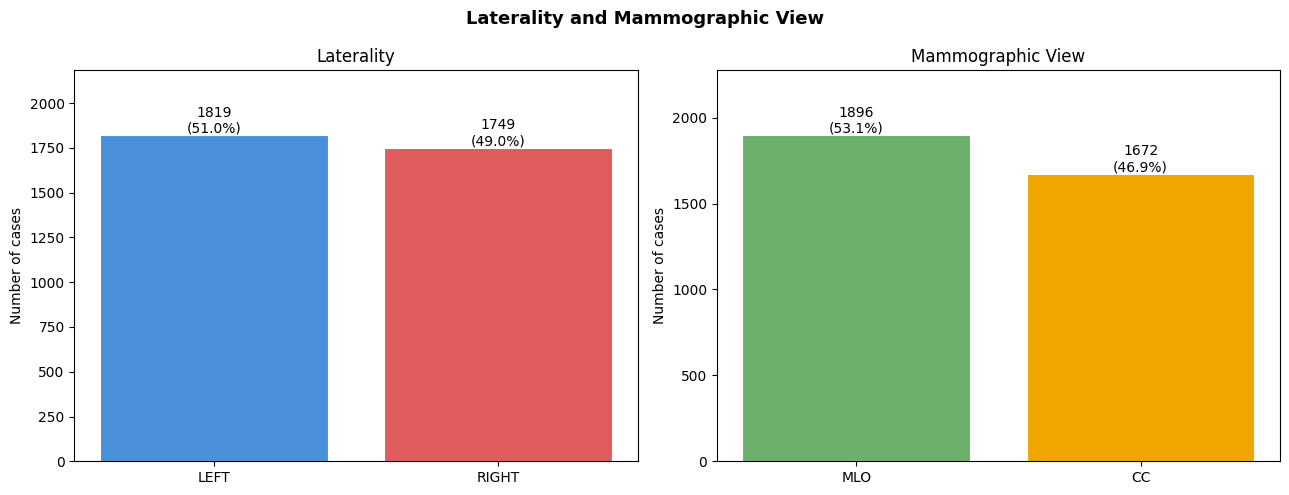

Laterality counts:
left or right breast
LEFT     1819
RIGHT    1749

View counts:
image view
MLO    1896
CC     1672


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Laterality and Mammographic View", fontsize=13, fontweight="bold")

# Plot 1: left vs right breast
lat_counts = df["left or right breast"].value_counts()
axes[0].bar(lat_counts.index, lat_counts.values, color=["#4A90D9", "#E05C5C"], edgecolor="white", linewidth=0.8)
axes[0].set_title("Laterality")
axes[0].set_ylabel("Number of cases")
for i, (idx, val) in enumerate(lat_counts.items()):
    pct = val / len(df) * 100
    axes[0].text(i, val + 15, f"{val}\n({pct:.1f}%)", ha="center", fontsize=10)
axes[0].set_ylim(0, lat_counts.max() * 1.2)


# Plot 2: CC vs MLO view
view_counts = df["image view"].value_counts()
axes[1].bar(view_counts.index, view_counts.values, color=["#6BAF6B", "#F0A500"], edgecolor="white", linewidth=0.8)
axes[1].set_title("Mammographic View")
axes[1].set_ylabel("Number of cases")
for i, (idx, val) in enumerate(view_counts.items()):
    pct = val / len(df) * 100
    axes[1].text(i, val + 15, f"{val}\n({pct:.1f}%)", ha="center", fontsize=10)
axes[1].set_ylim(0, view_counts.max() * 1.2)


plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "C2_laterality_view.png", dpi=150, bbox_inches="tight")
plt.show()

print("Laterality counts:")
print(df["left or right breast"].value_counts().to_string())
print("\nView counts:")
print(df["image view"].value_counts().to_string())

**c.** Mass shape and margin distribution

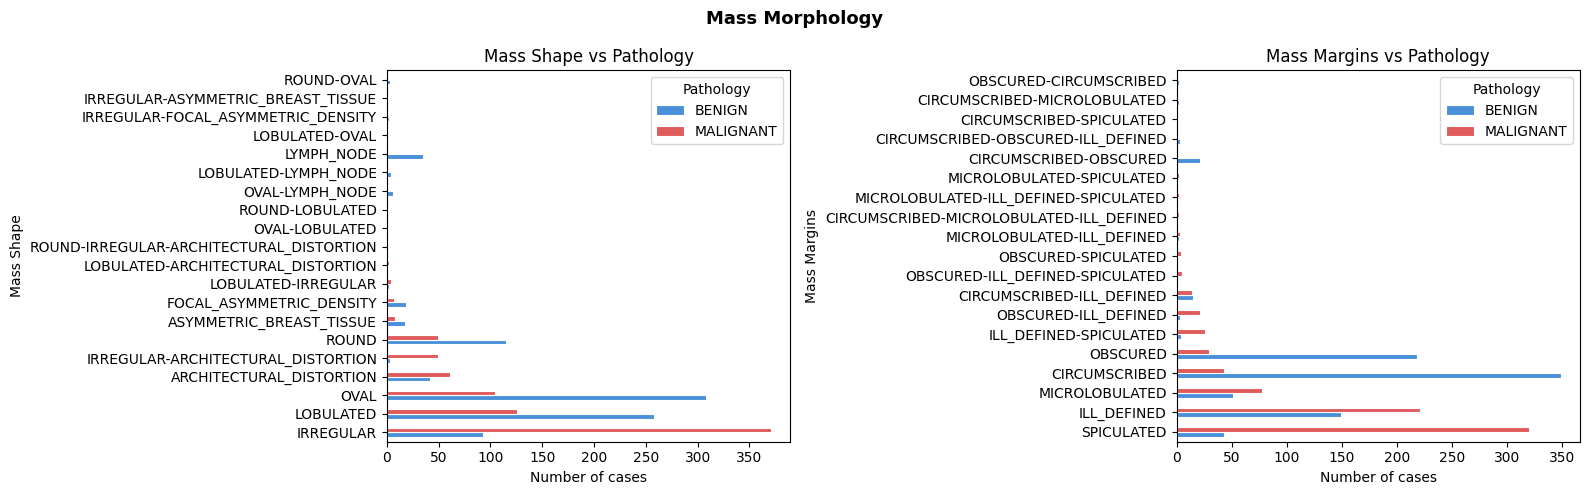

Mass shape by pathology:
pathology                                 BENIGN  MALIGNANT
mass shape                                                 
IRREGULAR                                     93        371
LOBULATED                                    258        126
OVAL                                         308        104
ARCHITECTURAL_DISTORTION                      42         61
IRREGULAR-ARCHITECTURAL_DISTORTION             3         49
ROUND                                        115         49
ASYMMETRIC_BREAST_TISSUE                      17          8
FOCAL_ASYMMETRIC_DENSITY                      18          7
LOBULATED-IRREGULAR                            2          4
LOBULATED-ARCHITECTURAL_DISTORTION             0          2
ROUND-IRREGULAR-ARCHITECTURAL_DISTORTION       0          1
OVAL-LOBULATED                                 1          0
ROUND-LOBULATED                                1          0
OVAL-LYMPH_NODE                                6          0
LOBULATED-LYMPH

In [ ]:
masses = df[df["abnormality type"] == "mass"].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Mass Morphology", fontsize=13, fontweight="bold")

# Plot 1: mass shape
shape_cross = (masses.groupby(["mass shape", "pathology"]).size().unstack(fill_value=0))
shape_cross = shape_cross.sort_values("MALIGNANT" if "MALIGNANT" in shape_cross.columns else shape_cross.columns[0], ascending=False)
colors = ["#4A90D9", "#E05C5C"]

shape_cross.plot(kind="barh", ax=axes[0], color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("Mass Shape vs Pathology")
axes[0].set_xlabel("Number of cases")
axes[0].set_ylabel("Mass Shape")
axes[0].legend(title="Pathology")


# Plot 2: mass margins
margin_cross = (masses.groupby(["mass margins", "pathology"]).size().unstack(fill_value=0))
margin_cross = margin_cross.sort_values("MALIGNANT" if "MALIGNANT" in margin_cross.columns else margin_cross.columns[0], ascending=False)

margin_cross.plot(kind="barh", ax=axes[1], color=colors, edgecolor="white", linewidth=0.8)
axes[1].set_title("Mass Margins vs Pathology")
axes[1].set_xlabel("Number of cases")
axes[1].set_ylabel("Mass Margins")
axes[1].legend(title="Pathology")


plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "C3_mass_morphology.png", dpi=150, bbox_inches="tight")
plt.show()

print("Mass shape by pathology:")
print(shape_cross.to_string())
print("\nMass margins by pathology:")
print(margin_cross.to_string())

**d.** Calification type and distribution

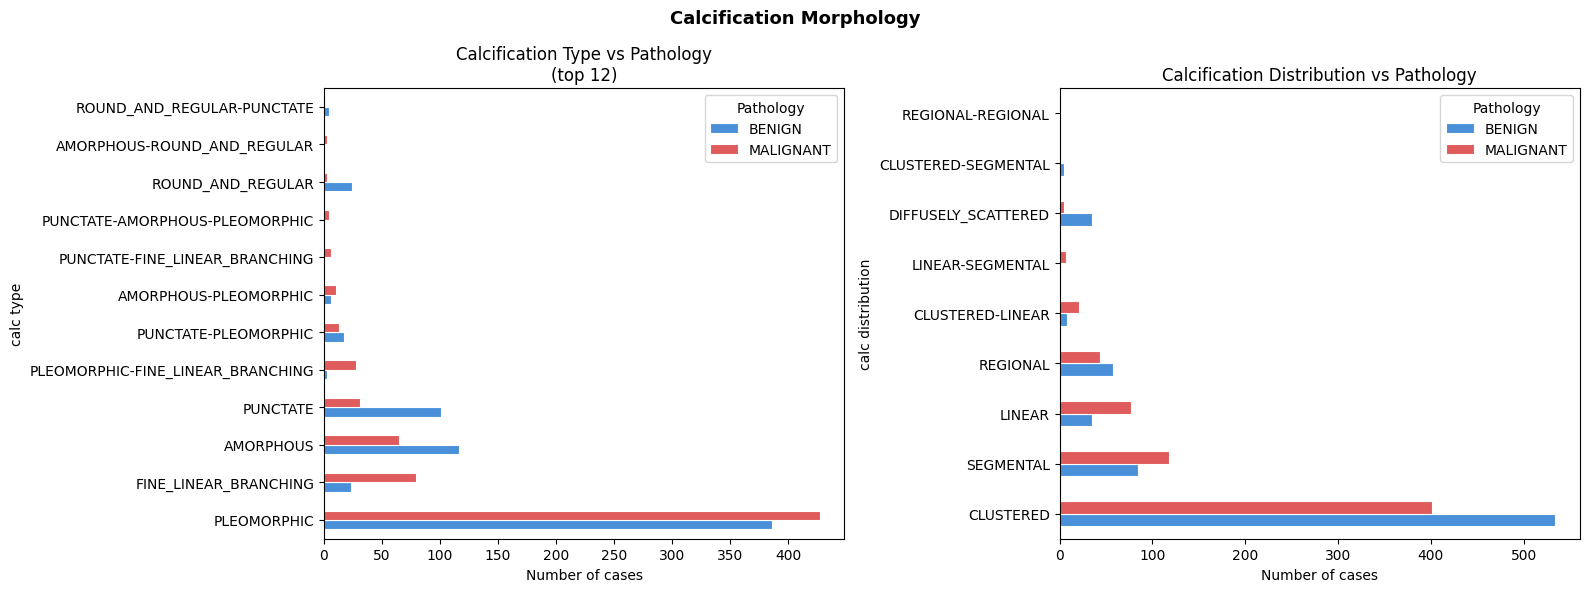

Calcification type by pathology (top 10):
pathology                          BENIGN  MALIGNANT
calc type                                           
PLEOMORPHIC                           386        427
FINE_LINEAR_BRANCHING                  23         79
AMORPHOUS                             116         65
PUNCTATE                              101         31
PLEOMORPHIC-FINE_LINEAR_BRANCHING       3         28
PUNCTATE-PLEOMORPHIC                   17         13
AMORPHOUS-PLEOMORPHIC                   6         10
PUNCTATE-FINE_LINEAR_BRANCHING          0          6
PUNCTATE-AMORPHOUS-PLEOMORPHIC          0          4
ROUND_AND_REGULAR                      24          3

Calcification distribution by pathology:
pathology            BENIGN  MALIGNANT
calc distribution                     
CLUSTERED               534        401
SEGMENTAL                84        118
LINEAR                   35         77
REGIONAL                 58         44
CLUSTERED-LINEAR          8         21
LINEAR-

In [ ]:
calcs = df[df["abnormality type"] == "calcification"].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Calcification Morphology", fontsize=13, fontweight="bold")

colors = ["#4A90D9", "#E05C5C"]

# Plot 1: calc type
type_cross = (calcs.groupby(["calc type", "pathology"]).size().unstack(fill_value=0))
type_cross = type_cross.sort_values("MALIGNANT" if "MALIGNANT" in type_cross.columns else type_cross.columns[0], ascending=False)
type_cross.head(12).plot(kind="barh", ax=axes[0], color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("Calcification Type vs Pathology\n(top 12)")
axes[0].set_xlabel("Number of cases")
axes[0].legend(title="Pathology")


# Plot 2: calc distribution
dist_cross = (calcs.groupby(["calc distribution", "pathology"]).size().unstack(fill_value=0))
dist_cross = dist_cross.sort_values("MALIGNANT" if "MALIGNANT" in dist_cross.columns else dist_cross.columns[0], ascending=False)
dist_cross.plot(kind="barh", ax=axes[1], color=colors, edgecolor="white", linewidth=0.8)
axes[1].set_title("Calcification Distribution vs Pathology")
axes[1].set_xlabel("Number of cases")
axes[1].legend(title="Pathology")


plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "C4_calc_morphology.png", dpi=150, bbox_inches="tight")
plt.show()

print("Calcification type by pathology (top 10):")
print(type_cross.head(10).to_string())
print("\nCalcification distribution by pathology:")
print(dist_cross.to_string())

**e.** Correlation analysis

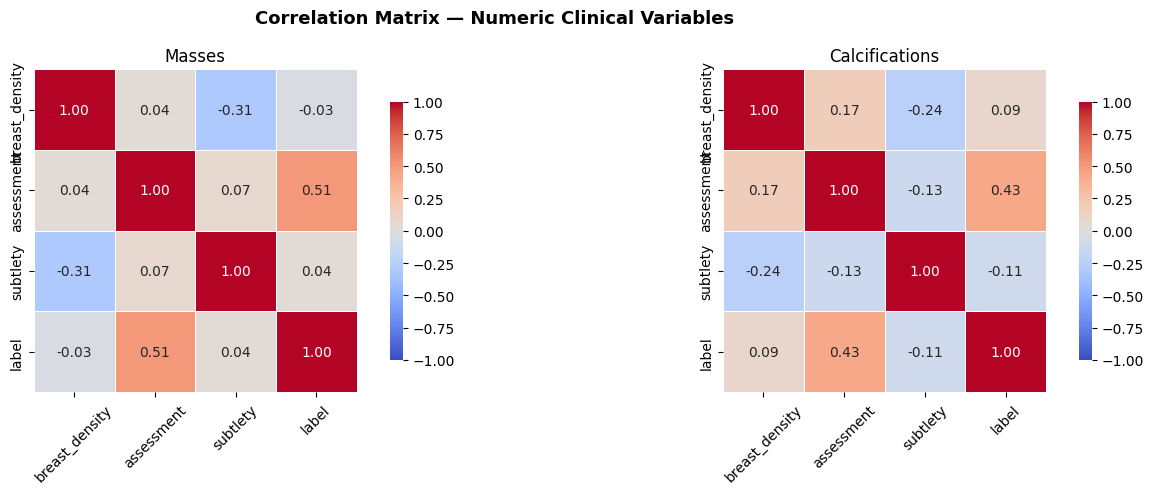

Correlation with label (masses):
assessment        0.505968
subtlety          0.042504
breast_density   -0.031435

Correlation with label (calcifications):
assessment        0.427531
breast_density    0.091411
subtlety         -0.106539


In [ ]:
numeric_cols = ["breast_density", "assessment", "subtlety", "label"]
existing_cols = [c for c in numeric_cols if c in df.columns]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Correlation Matrix — Numeric Clinical Variables", fontsize=13, fontweight="bold")

for ax, ftype in zip(axes, ["mass", "calcification"]):
    subset = df[df["abnormality type"] == ftype][existing_cols].dropna()
    corr = subset.corr()
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask, k=1)] = True

    sns.heatmap(corr, ax=ax, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
    title = "Masses" if ftype == "mass" else "Calcifications"
    ax.set_title(f"{title}")
    ax.tick_params(axis="x", rotation=45)


plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "C5_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Correlation with label (masses):")
mass_corr = df[df["abnormality type"]=="mass"][existing_cols].corr()["label"].drop("label")
print(mass_corr.sort_values(ascending=False).to_string())

print("\nCorrelation with label (calcifications):")
calc_corr = df[df["abnormality type"]=="calcification"][existing_cols].corr()["label"].drop("label")
print(calc_corr.sort_values(ascending=False).to_string())

**f.** Summary

In [ ]:
print("=" * 55)
print("CLINICAL VARIABLES SUMMARY")
print("=" * 55)

# dominant mass shape for malignant
if "mass shape" in masses.columns:
    top_mal_shape = (masses[masses["label"]==1]["mass shape"].value_counts().idxmax())
    top_ben_shape = (masses[masses["label"]==0]["mass shape"].value_counts().idxmax())
    print(f"  Most common malignant mass shape : {top_mal_shape}")
    print(f"  Most common benign mass shape    : {top_ben_shape}")

# dominant mass margin for malignant
if "mass margins" in masses.columns:
    top_mal_margin = (masses[masses["label"]==1]["mass margins"].value_counts().idxmax())
    top_ben_margin = (masses[masses["label"]==0]["mass margins"].value_counts().idxmax())
    print(f"  Most common malignant margin     : {top_mal_margin}")
    print(f"  Most common benign margin        : {top_ben_margin}")

print()

# dominant calc type for malignant
if "calc type" in calcs.columns:
    top_mal_calc = (calcs[calcs["label"]==1]["calc type"].value_counts().idxmax())
    top_ben_calc = (calcs[calcs["label"]==0]["calc type"].value_counts().idxmax())
    print(f"  Most common malignant calc type  : {top_mal_calc}")
    print(f"  Most common benign calc type     : {top_ben_calc}")

print()

# breast density most affected
top_density = df["breast_density"].value_counts().idxmax()
print(f"  Most frequent breast density     : {top_density}")
print(f"  Laterality balance               : "
      f"{df['left or right breast'].value_counts().to_dict()}")
print(f"  View balance                     : "
      f"{df['image view'].value_counts().to_dict()}")

print()
print("  Correlation with label (top variables):")
all_corr = df[existing_cols].corr()["label"].drop("label")
for col, val in all_corr.sort_values(ascending=False).items():
    direction = "positive" if val > 0 else "negative"
    print(f"    {col:20s}: {val:+.3f}  ({direction})")

print("=" * 55)

CLINICAL VARIABLES SUMMARY
  Most common malignant mass shape : IRREGULAR
  Most common benign mass shape    : OVAL
  Most common malignant margin     : SPICULATED
  Most common benign margin        : CIRCUMSCRIBED

  Most common malignant calc type  : PLEOMORPHIC
  Most common benign calc type     : PLEOMORPHIC

  Most frequent breast density     : 2.0
  Laterality balance               : {'LEFT': 1819, 'RIGHT': 1749}
  View balance                     : {'MLO': 1896, 'CC': 1672}

  Correlation with label (top variables):
    assessment          : +0.472  (positive)
    subtlety            : -0.012  (negative)


#### **4° EDA: DICOM Images Analysis**

**a.** Image dimensions distribution

Reading DICOM metadata from sample of full mammograms...
Metadata read for 300 records.


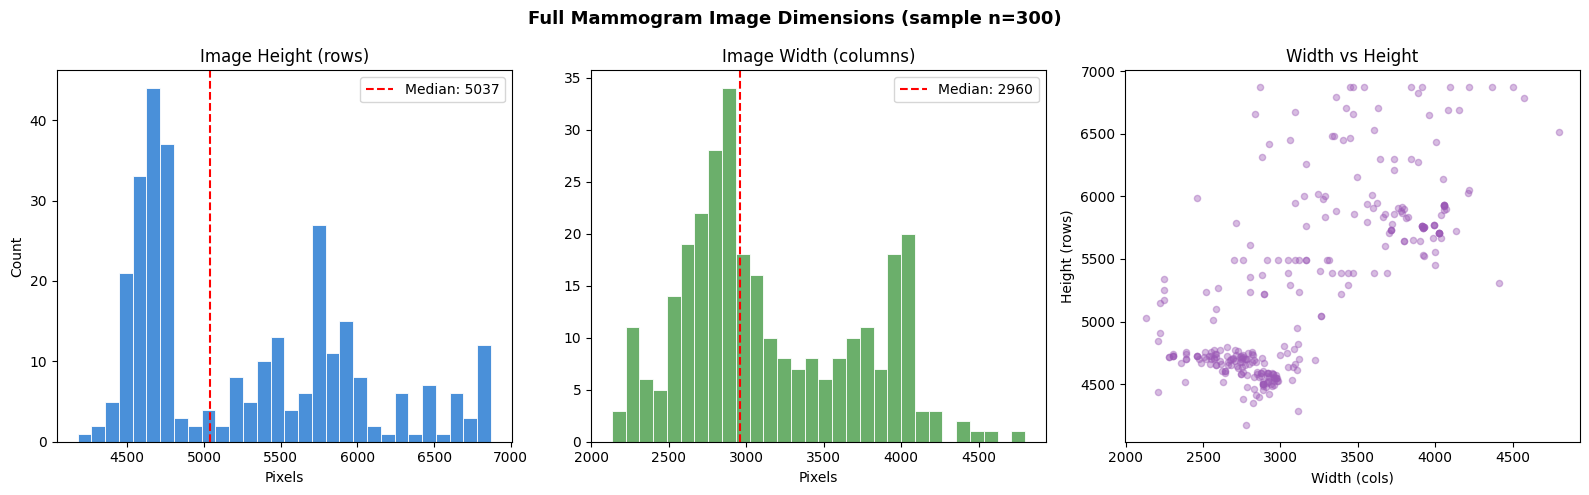


Image dimension statistics:
         rows    cols  bits_stored
count   300.0   300.0        300.0
mean   5266.0  3151.0         16.0
std     718.0   565.0          0.0
min    4176.0  2131.0         16.0
25%    4664.0  2744.0         16.0
50%    5037.0  2960.0         16.0
75%    5780.0  3666.0         16.0
max    6871.0  4801.0         16.0


In [ ]:
import warnings
warnings.filterwarnings("ignore")

def get_dicom_metadata(dcm_path: Path) -> dict:
    """
    Read basic metadata from a DICOM file without loading full pixel array.

    Parameters
    ----------
    dcm_path : Path
        Path to .dcm file.

    Returns
    -------
    dict with keys: rows, cols, bits_stored, manufacturer, pixel_spacing
    """
    try:
        ds = pydicom.dcmread(str(dcm_path), stop_before_pixels=True)
        return {
            "rows" : int(getattr(ds, "Rows", 0)),
            "cols" : int(getattr(ds, "Columns", 0)),
            "bits_stored" : int(getattr(ds, "BitsStored", 0)),
            "manufacturer" : str(getattr(ds, "Manufacturer", "UNKNOWN")).strip(),
            "pixel_spacing" : str(getattr(ds, "PixelSpacing", "N/A")),
        }
    except Exception as e:
        return {"rows": 0, "cols": 0, "bits_stored": 0,
                "manufacturer": "ERROR", "pixel_spacing": "N/A"}




# Sample metadata from full mammograms (first 300 records for speed)
print("Reading DICOM metadata from sample of full mammograms...")
sample_df = df[df["path_full_mammo"].notna()].head(300).copy()

meta_records = []
for i, row in sample_df.iterrows():
    meta = get_dicom_metadata(row["path_full_mammo"])
    meta["patient_id"]    = row["patient_id"]
    meta["abnormality type"]  = row["abnormality type"]
    meta["pathology"]     = row["pathology"]
    meta_records.append(meta)

meta_df = pd.DataFrame(meta_records)
print(f"Metadata read for {len(meta_df)} records.")

# Plot: image dimensions distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Full Mammogram Image Dimensions (sample n=300)", fontsize=13, fontweight="bold")

axes[0].hist(meta_df["rows"], bins=30, color="#4A90D9", edgecolor="white", linewidth=0.6)
axes[0].set_title("Image Height (rows)")
axes[0].set_xlabel("Pixels")
axes[0].set_ylabel("Count")
axes[0].axvline(meta_df["rows"].median(), color="red", linestyle="--", label=f"Median: {meta_df['rows'].median():.0f}")
axes[0].legend()

axes[1].hist(meta_df["cols"], bins=30, color="#6BAF6B",edgecolor="white", linewidth=0.6)
axes[1].set_title("Image Width (columns)")
axes[1].set_xlabel("Pixels")
axes[1].axvline(meta_df["cols"].median(), color="red", linestyle="--", label=f"Median: {meta_df['cols'].median():.0f}")
axes[1].legend()

axes[2].scatter(meta_df["cols"], meta_df["rows"], alpha=0.4, color="#9B59B6", s=20)
axes[2].set_title("Width vs Height")
axes[2].set_xlabel("Width (cols)")
axes[2].set_ylabel("Height (rows)")

plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "D1_image_dimensions.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nImage dimension statistics:")
print(meta_df[["rows", "cols", "bits_stored"]].describe().round(0).to_string())

**b.** Manufacturer distribution

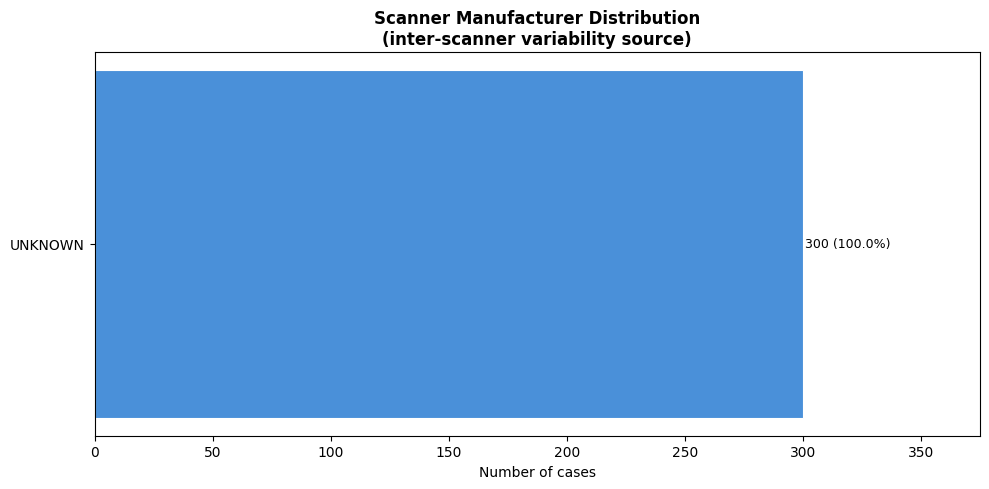

Manufacturer distribution:
manufacturer
UNKNOWN    300

Unique manufacturers: 1


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

manufacturer_counts = (meta_df["manufacturer"].value_counts().head(10))

bars = ax.barh(manufacturer_counts.index, manufacturer_counts.values, color="#4A90D9", edgecolor="white", linewidth=0.8)

ax.set_title("Scanner Manufacturer Distribution\n(inter-scanner variability source)", fontsize=12, fontweight="bold")
ax.set_xlabel("Number of cases")
ax.invert_yaxis()

for bar, val in zip(bars, manufacturer_counts.values):
    pct = val / len(meta_df) * 100
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"{val} ({pct:.1f}%)", va="center", fontsize=9)

ax.set_xlim(0, manufacturer_counts.max() * 1.25)
plt.tight_layout()
# plt.savefig(BASE / "D2_manufacturers.png", dpi=150, bbox_inches="tight")
plt.show()

print("Manufacturer distribution:")
print(manufacturer_counts.to_string())
n_manufacturers = meta_df["manufacturer"].nunique()
print(f"\nUnique manufacturers: {n_manufacturers}")
if n_manufacturers > 1:
    print("[!] Multiple manufacturers detected — inter-scanner")
    print("    variability must be addressed in preprocessing.")

In [ ]:
# Diagnose manufacturer tag
sample_path = df[df["path_full_mammo"].notna()].iloc[0]["path_full_mammo"]
ds = pydicom.dcmread(str(sample_path), stop_before_pixels=True)

print("All DICOM tags containing manufacturer-related info:")
for elem in ds:
    keyword = elem.keyword.lower() if elem.keyword else ""
    if any(term in keyword for term in
           ["manuf", "station", "model", "device", "institution"]):
        print(f"  [{elem.tag}] {elem.keyword}: {elem.value}")

print("\nFull tag list (first 30):")
for i, elem in enumerate(ds):
    if i >= 30:
        break
    print(f"  [{elem.tag}] {elem.keyword}: {str(elem.value)[:60]}")

All DICOM tags containing manufacturer-related info:
  [(0018,1016)] SecondaryCaptureDeviceManufacturer: MathWorks
  [(0018,1018)] SecondaryCaptureDeviceManufacturerModelName: MATLAB

Full tag list (first 30):
  [(0008,0005)] SpecificCharacterSet: ISO_IR 100
  [(0008,0016)] SOPClassUID: 1.2.840.10008.5.1.4.1.1.7
  [(0008,0018)] SOPInstanceUID: 1.3.6.1.4.1.9590.100.1.2.15655687301098164651712887431212934
  [(0008,0020)] StudyDate: 20160720
  [(0008,0023)] ContentDate: 20160414
  [(0008,0030)] StudyTime: 181327
  [(0008,0033)] ContentTime: 121658.138000
  [(0008,0050)] AccessionNumber: 
  [(0008,0060)] Modality: MG
  [(0008,0064)] ConversionType: WSD
  [(0008,0090)] ReferringPhysicianName: 
  [(0008,103E)] SeriesDescription: full mammogram images
  [(0010,0010)] PatientName: Mass-Training_P_00001_LEFT_CC
  [(0010,0020)] PatientID: Mass-Training_P_00001_LEFT_CC
  [(0010,0030)] PatientBirthDate: 
  [(0010,0040)] PatientSex: 
  [(0013,0010)] : CTP
  [(0013,1010)] : b'CBIS-DDSM '
  [(0013,10

In [ ]:
# Check photometric interpretation
print("Photometric interpretation in sample:")
sample_records = []

for _, row in df[df["path_full_mammo"].notna()].head(50).iterrows():
    try:
        ds = pydicom.dcmread(str(row["path_full_mammo"]),
                             stop_before_pixels=True)
        photo = str(getattr(ds, "PhotometricInterpretation", "N/A"))
        bits  = int(getattr(ds, "BitsStored", 0))
        sample_records.append({
            "patient_id"  : row["patient_id"],
            "abnormality type": row["abnormality type"],
            "photometric" : photo,
            "bits_stored" : bits,
        })
    except Exception:
        pass

photo_df = pd.DataFrame(sample_records)

print("Photometric interpretation counts:")
print(photo_df["photometric"].value_counts().to_string())
print("\nBits stored counts:")
print(photo_df["bits_stored"].value_counts().to_string())
print("\nSample records:")
print(photo_df.head(8).to_string())

Photometric interpretation in sample:
Photometric interpretation counts:
photometric
MONOCHROME2    50

Bits stored counts:
bits_stored
16    50

Sample records:
  patient_id abnormality type  photometric  bits_stored
0    P_00001             mass  MONOCHROME2           16
1    P_00001             mass  MONOCHROME2           16
2    P_00004             mass  MONOCHROME2           16
3    P_00004             mass  MONOCHROME2           16
4    P_00004             mass  MONOCHROME2           16
5    P_00009             mass  MONOCHROME2           16
6    P_00009             mass  MONOCHROME2           16
7    P_00015             mass  MONOCHROME2           16


**c.** Pixel intensity distribution

Reading pixel statistics from cropped ROI images (sample n=200)...
Pixel stats computed for 200 records.


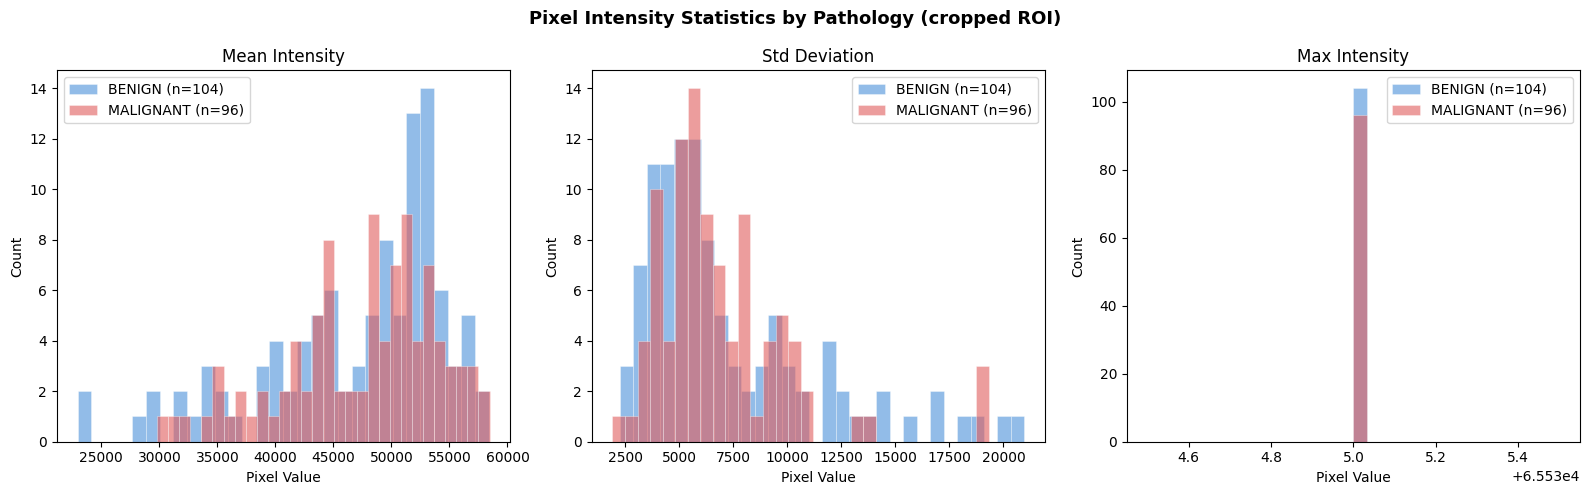


Pixel statistics by pathology:
          pix_mean                                                               pix_std                                                          pix_max                                                           
             count     mean     std      min      25%      50%      75%      max   count    mean     std     min     25%     50%     75%      max   count     mean  std      min      25%      50%      75%      max
pathology                                                                                                                                                                                                           
BENIGN       104.0  47003.1  7872.9  22944.1  42963.5  49664.9  52724.6  58378.9   104.0  7246.5  4145.4  2245.5  4615.9  5715.7  9193.1  20974.4   104.0  65535.0  0.0  65535.0  65535.0  65535.0  65535.0  65535.0
MALIGNANT     96.0  47414.7  6557.6  29803.0  43687.9  48601.4  52292.9  58451.8    96.0  6901.3  3188.0  1897.6  50

In [ ]:
def get_pixel_stats(dcm_path: Path) -> dict:
    """
    Read pixel array and compute basic intensity statistics.

    Parameters
    ----------
    dcm_path : Path
        Path to .dcm file.

    Returns
    -------
    dict with min, max, mean, std, median pixel values.
    """
    try:
        ds = pydicom.dcmread(str(dcm_path))
        pixels = ds.pixel_array.astype(np.float32)
        return {
            "pix_min" : float(pixels.min()),
            "pix_max" : float(pixels.max()),
            "pix_mean" : float(pixels.mean()),
            "pix_std" : float(pixels.std()),
            "pix_median" : float(np.median(pixels)),
        }
    except Exception:
        return {"pix_min": np.nan, "pix_max": np.nan,
                "pix_mean": np.nan, "pix_std": np.nan,
                "pix_median": np.nan}


# Sample pixel stats from cropped ROI images (faster than full mammograms)
print("Reading pixel statistics from cropped ROI images (sample n=200)...")
sample_crop = df[df["path_cropped"].notna()].head(200).copy()

pix_records = []
for i, row in sample_crop.iterrows():
    stats = get_pixel_stats(row["path_cropped"])
    stats["pathology"] = row["pathology"]
    stats["abnormality type"] = row["abnormality type"]
    pix_records.append(stats)

pix_df = pd.DataFrame(pix_records).dropna()
print(f"Pixel stats computed for {len(pix_df)} records.")

# Plot: intensity distributions by pathology 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Pixel Intensity Statistics by Pathology (cropped ROI)", fontsize=13, fontweight="bold")

metrics = ["pix_mean", "pix_std", "pix_max"]
titles = ["Mean Intensity", "Std Deviation", "Max Intensity"]
colors = {"BENIGN": "#4A90D9", "MALIGNANT": "#E05C5C"}

for ax, metric, title in zip(axes, metrics, titles):
    for pathology, color in colors.items():
        subset = pix_df[pix_df["pathology"] == pathology][metric]
        ax.hist(subset, bins=30, alpha=0.6, color=color, edgecolor="white", linewidth=0.4, label=f"{pathology} (n={len(subset)})")
    ax.set_title(title)
    ax.set_xlabel("Pixel Value")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "D3_pixel_intensities.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nPixel statistics by pathology:")
print(pix_df.groupby("pathology")[metrics].describe().round(1).to_string())

**d.** Sample case visualization

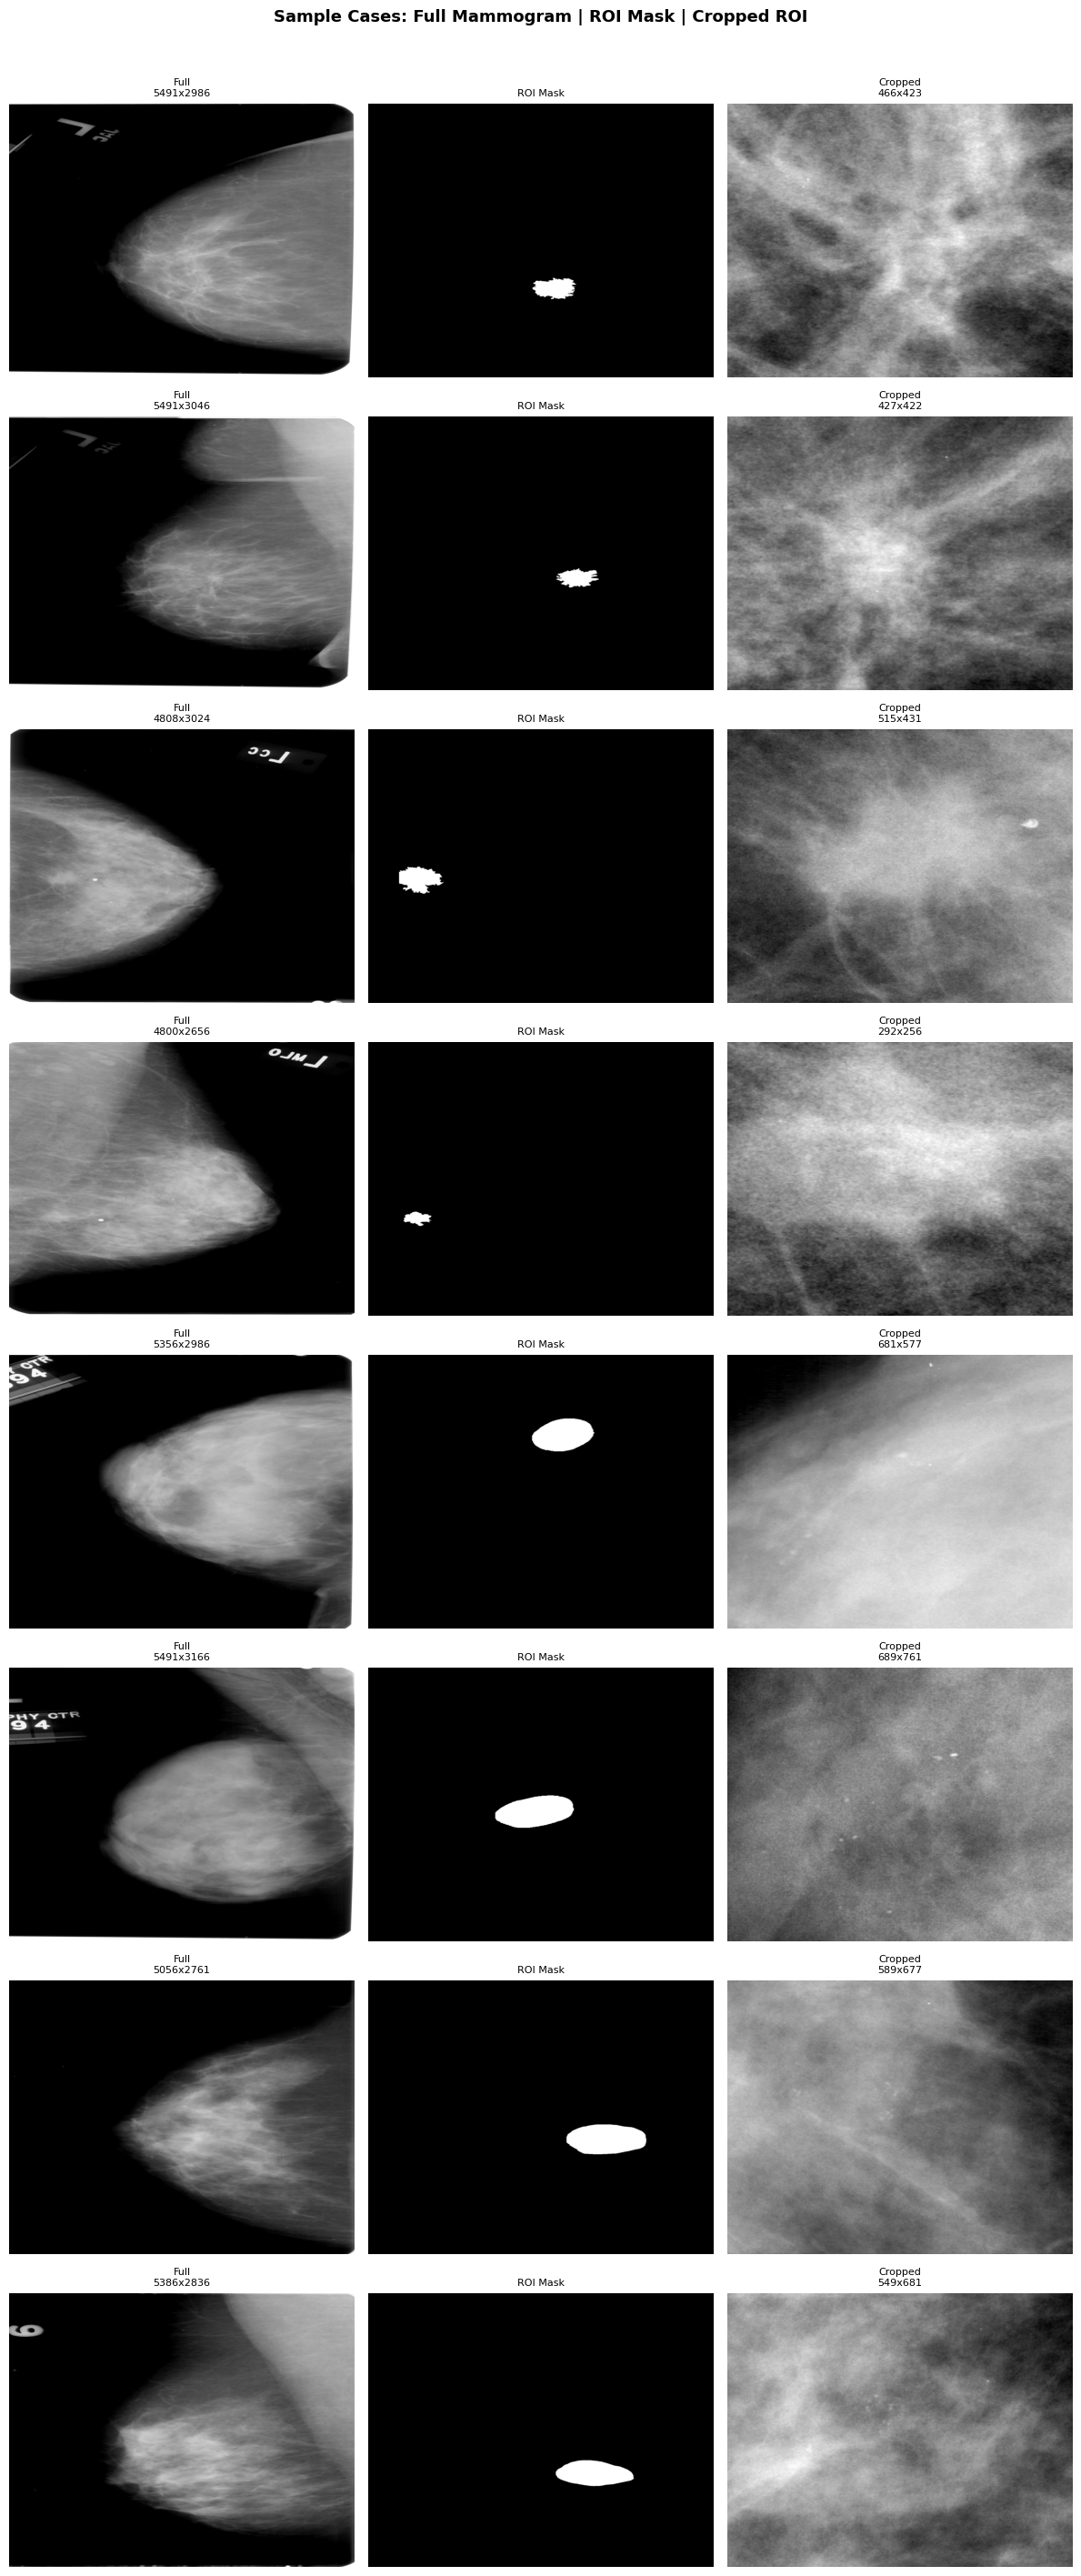

Gallery saved: 8 cases displayed.


In [ ]:
def normalize_pixels(pixels: np.ndarray) -> np.ndarray:
    """Normalize pixel array to [0, 1] for display."""
    pmin, pmax = pixels.min(), pixels.max()
    if pmax == pmin:
        return np.zeros_like(pixels, dtype=np.float32)
    return (pixels - pmin) / (pmax - pmin)


def show_case(ax_full, ax_mask, ax_crop, row: pd.Series) -> None:
    """
    Display full mammogram, ROI mask and cropped image for one case.
    """
    # full mammogram (downsampled for display)
    if pd.notna(row["path_full_mammo"]):
        full = pydicom.dcmread(str(row["path_full_mammo"])).pixel_array
        full_norm = normalize_pixels(full.astype(np.float32))
        ax_full.imshow(full_norm, cmap="gray", aspect="auto")
        ax_full.set_title(f"Full\n{full.shape[0]}x{full.shape[1]}",
                          fontsize=8)
    ax_full.axis("off")

    # ROI mask
    if pd.notna(row["path_roi_mask"]):
        mask = pydicom.dcmread(str(row["path_roi_mask"])).pixel_array
        ax_mask.imshow(mask, cmap="gray", aspect="auto")
        ax_mask.set_title("ROI Mask", fontsize=8)
    ax_mask.axis("off")

    # cropped ROI
    if pd.notna(row["path_cropped"]):
        crop = pydicom.dcmread(str(row["path_cropped"])).pixel_array
        crop_norm = normalize_pixels(crop.astype(np.float32))
        ax_crop.imshow(crop_norm, cmap="gray", aspect="auto")
        ax_crop.set_title(f"Cropped\n{crop.shape[0]}x{crop.shape[1]}",
                          fontsize=8)
    ax_crop.axis("off")


# Select 2 benign and 2 malignant cases per finding type
samples = []
for ftype in ["mass", "calcification"]:
    for label in [0, 1]:
        subset = df[
            (df["abnormality type"] == ftype) &
            (df["label"] == label) &
            (df["path_full_mammo"].notna()) &
            (df["path_roi_mask"].notna()) &
            (df["path_cropped"].notna())
        ].head(2)
        samples.append(subset)

samples_df = pd.concat(samples, ignore_index=True)

n_cases = len(samples_df)
fig, axes = plt.subplots(n_cases, 3, figsize=(12, n_cases * 3.5))
fig.suptitle("Sample Cases: Full Mammogram | ROI Mask | Cropped ROI", fontsize=13, fontweight="bold", y=1.01)

for i, (_, row) in enumerate(samples_df.iterrows()):
    label_str = "MALIGNANT" if row["label"] == 1 else "BENIGN"
    ftype_str = row["abnormality type"].upper()
    row_label = f"{ftype_str} — {label_str}"
    axes[i, 0].set_ylabel(row_label, fontsize=9, fontweight="bold", rotation=90, labelpad=8)
    show_case(axes[i, 0], axes[i, 1], axes[i, 2], row)

plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "D4_sample_gallery.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Gallery saved: {n_cases} cases displayed.")

**e.** Overlay visualization of ROI masks

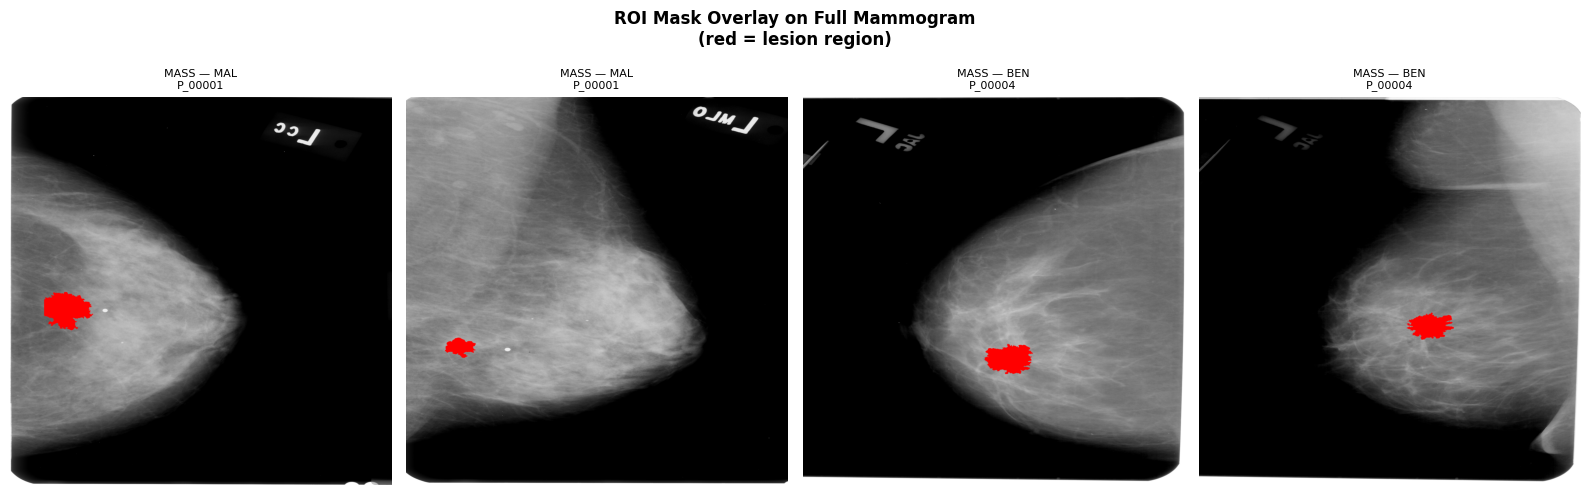

In [ ]:
def overlay_mask(full_pixels: np.ndarray, mask_pixels: np.ndarray) -> np.ndarray:
    """
    Create an RGB overlay of the ROI mask on the full mammogram.
    Mask region is highlighted in red.

    Parameters
    ----------
    full_pixels : np.ndarray
        2D grayscale pixel array of the full mammogram.
    mask_pixels : np.ndarray
        2D binary pixel array of the ROI mask.

    Returns
    -------
    np.ndarray
        RGB image (H, W, 3) with red overlay on mask region.
    """
    full_norm = normalize_pixels(full_pixels.astype(np.float32))

    # resize mask to match full mammogram if shapes differ
    if full_norm.shape != mask_pixels.shape:
        from skimage.transform import resize
        mask_resized = resize(mask_pixels.astype(np.float32), full_norm.shape, anti_aliasing=False) > 0.5
    else:
        mask_resized = mask_pixels > 0

    # build RGB overlay
    rgb = np.stack([full_norm, full_norm, full_norm], axis=-1)
    rgb[mask_resized, 0] = 1.0   # red channel
    rgb[mask_resized, 1] = 0.0   # green channel
    rgb[mask_resized, 2] = 0.0   # blue channel
    return rgb


# Show 4 overlay examples
overlay_samples = df[(df["path_full_mammo"].notna()) & (df["path_roi_mask"].notna())].head(4)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle("ROI Mask Overlay on Full Mammogram\n(red = lesion region)", fontsize=12, fontweight="bold")

for ax, (_, row) in zip(axes, overlay_samples.iterrows()):
    try:
        full = pydicom.dcmread(str(row["path_full_mammo"])).pixel_array
        mask = pydicom.dcmread(str(row["path_roi_mask"])).pixel_array
        overlay = overlay_mask(full, mask)
        ax.imshow(overlay, aspect="auto")
        label_str = "MAL" if row["label"] == 1 else "BEN"
        ax.set_title(f"{row['abnormality type'].upper()} — {label_str}\n"
                     f"{row['patient_id']}", fontsize=8)
    except Exception as e:
        ax.set_title(f"Error: {e}", fontsize=7)
    ax.axis("off")

plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "D5_roi_overlays.png", dpi=120, bbox_inches="tight")
plt.show()

**f.** Summary

In [45]:
print("=" * 60)
print("DICOM IMAGE ANALYSIS SUMMARY")
print("=" * 60)
print(f"  Sample size analyzed          : {len(meta_df)} full mammograms")
print(f"  Median image height           : {meta_df['rows'].median():.0f} px")
print(f"  Median image width            : {meta_df['cols'].median():.0f} px")
print(f"  Most common bit depth         : "
      f"{meta_df['bits_stored'].mode()[0]}-bit")
print(f"  Unique manufacturers          : {meta_df['manufacturer'].nunique()}")
print(f"  Top manufacturer              : "
      f"{meta_df['manufacturer'].value_counts().idxmax()}")
print()
print(f"  Pixel stats (cropped ROI, n={len(pix_df)}):")
for pathology in ["BENIGN", "MALIGNANT"]:
    sub = pix_df[pix_df["pathology"] == pathology]
    print(f"    {pathology:10s} — mean: {sub['pix_mean'].mean():7.1f}  "
          f"std: {sub['pix_std'].mean():6.1f}  "
          f"max: {sub['pix_max'].mean():7.1f}")

DICOM IMAGE ANALYSIS SUMMARY
  Sample size analyzed          : 300 full mammograms
  Median image height           : 5037 px
  Median image width            : 2960 px
  Most common bit depth         : 16-bit
  Unique manufacturers          : 1
  Top manufacturer              : UNKNOWN

  Pixel stats (cropped ROI, n=200):
    BENIGN     — mean: 47003.1  std: 7246.5  max: 65535.0
    MALIGNANT  — mean: 47414.7  std: 6901.3  max: 65535.0
